In [1]:
from pathlib import Path
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markerlist = ["o", "s", "D"]

mpl.rcParams["font.size"] = 14

BASERESULTSDIR = Path("out/")

In [3]:
pbc_labels = ["pbc-FFF", "pbc-TTT"]
labelmap_quantities = {
    "dr": r"$\nabla_i U^{1+}$",
    "dq": r"$\frac{\partial U^{1+}}{\partial q_i}$",
    "energy_and_dr_and_dq": r"$\left(U^{1+}, \, \nabla_i U^{1+}, \, \frac{\partial U^{1+}}{\partial q_i}\right)$",
}
labelmap_customderivs = {
    "energy": "$U^{1+}$",
    "defaultgrad": "default autodiff",
    "customjvp": "opt. derivative",
}

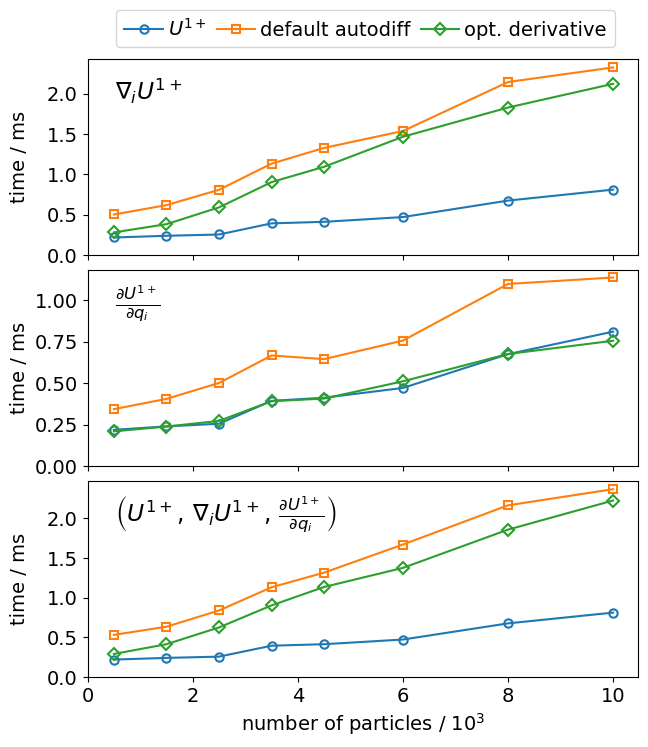

In [4]:
BASERESULTSDIR = Path("out/")

# LBL_PBC = pbc_labels[0]
LBL_PBC = pbc_labels[1]

filename_without_suffix = "timing_default_vs_custom_grad" + "__" + LBL_PBC

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    figsize=(6.4, 7.4),
)
axs[-1].set_xlabel("number of particles / $10^3$")

for (quantity_identifier, quantity_nice_label), ax in zip(
    labelmap_quantities.items(), axs
):
    ax.set_title(quantity_nice_label, x=0.05, y=0.75, ha="left")
    ax.set_ylabel("time / ms")

    for (deriv_identifier, deriv_nice_label), color, marker in zip(
        labelmap_customderivs.items(), default_colors, markerlist
    ):
        dirname = "__".join([LBL_PBC, deriv_identifier])
        if deriv_identifier != "energy":
            dirname += "__" + quantity_identifier
        resultsdir = BASERESULTSDIR / dirname
        try:
            nbs_particles = onp.loadtxt(
                resultsdir / "times_vs_n_particles.txt", usecols=0, dtype=int
            )
            times = onp.loadtxt(
                resultsdir / "times_vs_n_particles.txt", usecols=1, dtype=float
            )
        except FileNotFoundError:
            continue
        ax.plot(
            nbs_particles / 1000,
            times * 1000,
            label=deriv_nice_label,
            marker=marker,
            color=color,
            markerfacecolor="none",
            markeredgewidth=1.5,
        )

    ax.set_xlim(0, ax.get_xlim()[1])
    ax.set_ylim(0, ax.get_ylim()[1])

plt.subplots_adjust(
    left=0.13, right=0.99, bottom=0.09, top=0.925, hspace=0.075
)
fig.align_ylabels()
axs[0].legend(
    ncols=3,
    handletextpad=0.25,
    columnspacing=0.5,
    bbox_to_anchor=(0.975, 1.3),
    bbox_transform=axs[0].transAxes,
)

for suffix in ["png", "pdf"]:
    filename_plot = filename_without_suffix + "." + suffix
    fig.savefig(BASERESULTSDIR / (filename_plot))

plt.show()